In [53]:
from google.colab import files

uploaded = files.upload()


Saving WhatsApp Image 2026-05-26 at 1.52.10 PM.jpeg to WhatsApp Image 2026-05-26 at 1.52.10 PM (20).jpeg


## **Lectura y visualizacion**

Se utilizó OpenCV (cv2) para el análisis de la imagen. Debido a que OpenCV carga las imágenes en formato BGR, fue necesario convertirlas a RGB para mantener la representación correcta de los colores durante el procesamiento.

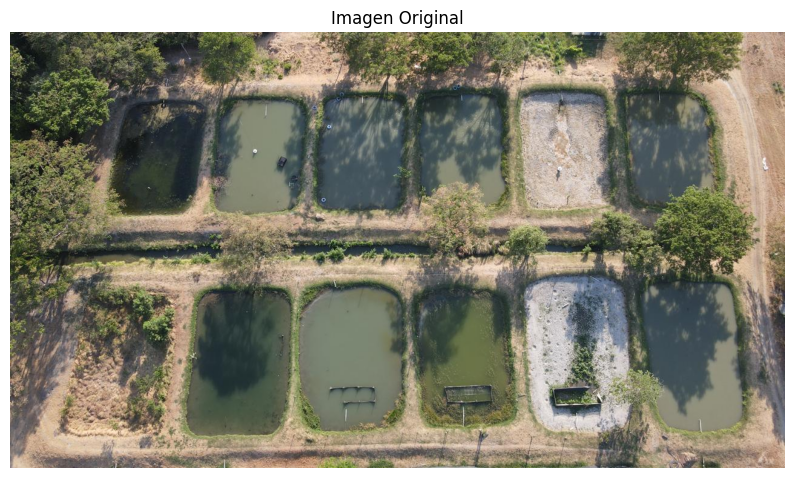

In [54]:
import cv2
import matplotlib.pyplot as plt

# Obtener nombre del archivo subido
nombre_imagen = list(uploaded.keys())[0]

# Leer imagen
img_bgr = cv2.imread(nombre_imagen)

# Convertir BGR -> RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar imagen
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis("off")
plt.show()


## **Imagen como Señal Espacial Discreta**

Una imagen digital puede entenderse como una **señal espacial discreta** porque está compuesta por una cuadrícula finita de elementos, conocidos como **píxeles**. Cada píxel tiene una posición específica (coordenadas x, y) y un valor numérico que representa su intensidad o color. Al ver la imagen completa, percibimos una continuidad, pero a nivel fundamental, es un conjunto de datos discretos.

Podemos demostrar esto observando las dimensiones de la imagen y los valores de intensidad de los píxeles en una pequeña sección.

In [55]:
import numpy as np

# Asumiendo que 'img_rgb' ya está cargada y es la imagen completa en formato RGB

print(f"Dimensiones de la imagen (alto, ancho, canales): {img_rgb.shape}")
print(f"Tipo de datos de los píxeles: {img_rgb.dtype}")

# Seleccionar una pequeña región de la imagen (por ejemplo, 10x10 píxeles)
# Esto nos permite ver los valores numéricos discretos de los píxeles
region_ejemplo = img_rgb[100:105, 100:105] # Selecciona una región de 5x5 píxeles

print("\nValores de píxeles (RGB) para una región de 5x5:\n")
for row in region_ejemplo:
    print(row)

print("\nObserva que cada elemento en el array representa un píxel en una ubicación específica, y cada píxel tiene 3 valores (R, G, B) que son números discretos entre 0 y 255.")

# También podemos ver un solo canal para ilustrar aún más la idea de una señal 2D
# Asumiendo que 'R' (canal rojo) ya ha sido extraído
print(f"\nDimensiones del canal Rojo (alto, ancho): {R.shape}")
print("Valores de píxeles para una región de 5x5 en el canal Rojo:\n")
print(R[100:105, 100:105])


Dimensiones de la imagen (alto, ancho, canales): (720, 1280, 3)
Tipo de datos de los píxeles: uint8

Valores de píxeles (RGB) para una región de 5x5:

[[ 61  72  38]
 [ 66  77  43]
 [ 82  92  57]
 [104 115  75]
 [109 121  75]]
[[50 61 29]
 [43 54 20]
 [51 61 24]
 [74 85 43]
 [82 94 46]]
[[ 52  61  32]
 [ 61  70  39]
 [ 82  92  57]
 [115 126  84]
 [119 128  81]]
[[ 35  43  19]
 [ 71  80  53]
 [108 118  84]
 [104 115  75]
 [116 125  80]]
[[ 49  53  36]
 [ 93  98  76]
 [ 97 103  75]
 [ 82  89  55]
 [ 90  99  56]]

Observa que cada elemento en el array representa un píxel en una ubicación específica, y cada píxel tiene 3 valores (R, G, B) que son números discretos entre 0 y 255.

Dimensiones del canal Rojo (alto, ancho): (720, 1280)
Valores de píxeles para una región de 5x5 en el canal Rojo:

[[ 61  66  82 104 109]
 [ 50  43  51  74  82]
 [ 52  61  82 115 119]
 [ 35  71 108 104 116]
 [ 49  93  97  82  90]]


# **Caracteristicas de la imagen: resolucion, analisis de sombras, ruido y perspectiva**

--- 1. Análisis de Resolución ---
La imagen original tiene una resolución de 1280x720 píxeles.
Cada píxel contiene 3 canales de color (R, G, B).

--- 2. Análisis de Sombras ---


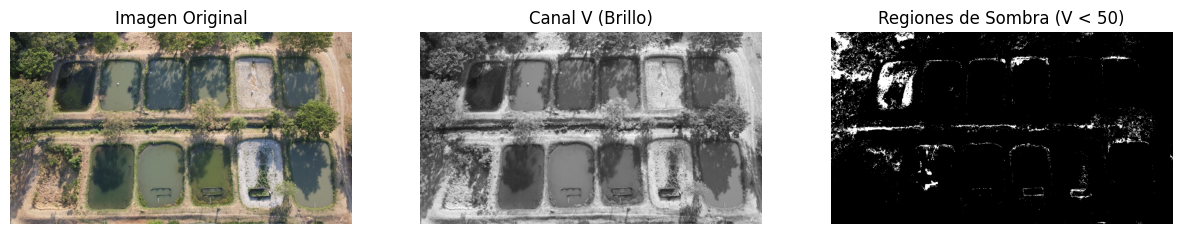

Las regiones en blanco en la última imagen indican posibles sombras.
Valores de brillo (V) promedio en la imagen: 124.21
Porcentaje de píxeles en sombra: 4.84%

--- 3. Análisis de Ruido ---
Desviación estándar de los píxeles (Canal R): 55.92
Desviación estándar de los píxeles (Canal G): 45.89
Desviación estándar de los píxeles (Canal B): 42.09


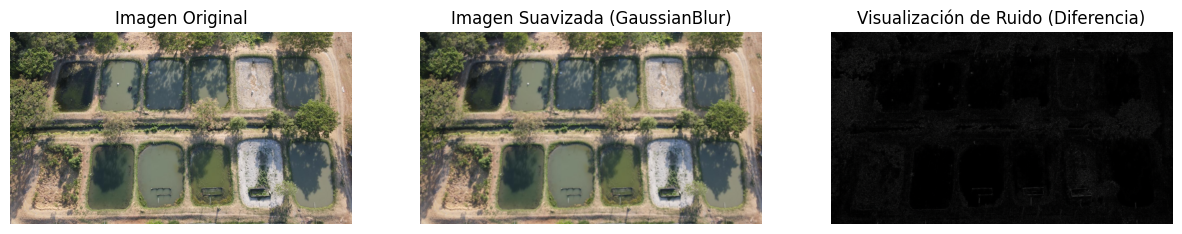

Las áreas más claras en la imagen de 'Diferencia' pueden indicar la presencia de ruido o detalles finos.
Un valor alto de desviación estándar en canales que deberían ser 'planos' podría indicar ruido.

--- 4. Análisis de Perspectiva ---
En esta imagen, la perspectiva se observa en cómo los objetos más distantes (como las piscinas más lejanas) parecen más pequeños que los objetos más cercanos, incluso si en realidad tienen un tamaño similar.
La imagen fue tomada desde un dron, lo que generalmente minimiza la distorsión de perspectiva en comparación con tomas a nivel del suelo. Sin embargo, aún puede haber una ligera distorsión en los bordes debido a la lente de la cámara y el ángulo de la toma.


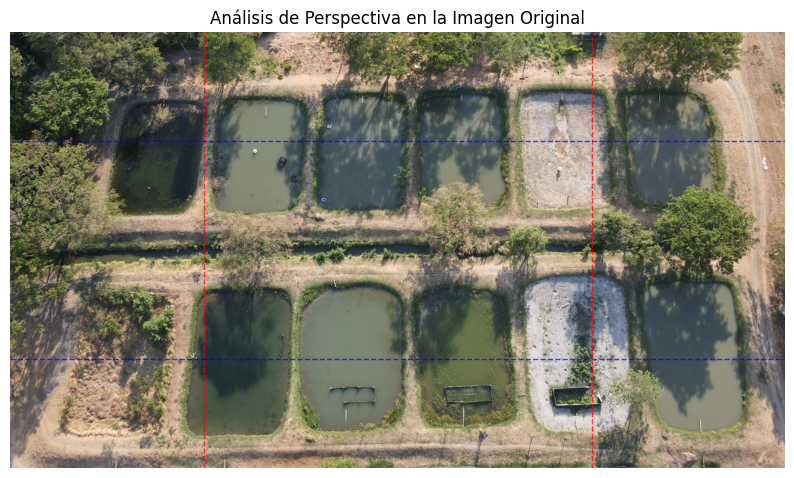

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Asegúrate de que 'img_rgb' esté disponible de celdas anteriores

print("--- 1. Análisis de Resolución ---")
height, width, channels = img_rgb.shape
print(f"La imagen original tiene una resolución de {width}x{height} píxeles.")
print(f"Cada píxel contiene {channels} canales de color (R, G, B).")

print("\n--- 2. Análisis de Sombras ---")
# Convertir la imagen completa a HSV para analizar el canal V (Brillo)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
value_channel = img_hsv[:, :, 2] # Extraer el canal de Valor (Brillo)

# Definir un umbral para identificar regiones oscuras (sombras)
# Este umbral puede necesitar ajuste dependiendo de la imagen
shadow_threshold = 50 # Valores de V por debajo de 50 se consideran sombras
shadow_mask = value_channel < shadow_threshold

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(value_channel, cmap='gray')
plt.title("Canal V (Brillo)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(shadow_mask, cmap='gray')
plt.title(f"Regiones de Sombra (V < {shadow_threshold})")
plt.axis("off")
plt.show()

print("Las regiones en blanco en la última imagen indican posibles sombras.")
print(f"Valores de brillo (V) promedio en la imagen: {np.mean(value_channel):.2f}")
print(f"Porcentaje de píxeles en sombra: {(np.sum(shadow_mask) / (height * width)) * 100:.2f}%")


print("\n--- 3. Análisis de Ruido ---")
# Una forma simple de estimar el ruido es calcular la desviación estándar de la intensidad de los píxeles.
# En una imagen idealmente 'plana' o sin ruido, la desviación estándar sería baja. Aquí, calculamos
# la desviación estándar para cada canal. Una desviación estándar alta puede indicar textura o ruido.

std_dev_R = np.std(img_rgb[:, :, 0])
std_dev_G = np.std(img_rgb[:, :, 1])
std_dev_B = np.std(img_rgb[:, :, 2])

print(f"Desviación estándar de los píxeles (Canal R): {std_dev_R:.2f}")
print(f"Desviación estándar de los píxeles (Canal G): {std_dev_G:.2f}")
print(f"Desviación estándar de los píxeles (Canal B): {std_dev_B:.2f}")

# Para una estimación visual del ruido, podemos comparar la imagen original
# con una versión ligeramente suavizada. Las diferencias pueden acentuar el ruido.
blurred_img = cv2.GaussianBlur(img_rgb, (5, 5), 0)
noise_visualization = cv2.absdiff(img_rgb, blurred_img)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred_img)
plt.title("Imagen Suavizada (GaussianBlur)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(noise_visualization, cmap='gray')
plt.title("Visualización de Ruido (Diferencia)")
plt.axis("off")
plt.show()

print("Las áreas más claras en la imagen de 'Diferencia' pueden indicar la presencia de ruido o detalles finos.\nUn valor alto de desviación estándar en canales que deberían ser 'planos' podría indicar ruido.")

print("\n--- 4. Análisis de Perspectiva ---")
# La perspectiva se refiere a cómo los objetos en una escena parecen cambiar de tamaño
# y forma a medida que se alejan del observador (cámara). En imágenes de drones,
# la perspectiva a menudo implica objetos que se vuelven más pequeños y líneas paralelas
# que convergen en puntos de fuga, aunque en una vista aérea cenital o casi cenital,
# este efecto puede ser menos pronunciado.

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Análisis de Perspectiva en la Imagen Original")
plt.axis("off")

# Añadir algunas líneas de guía para ilustrar la perspectiva (ejemplo)
# Estas líneas son solo ilustrativas y podrían no coincidir perfectamente con la imagen
# Dibuja líneas para simular una cuadrícula que converge
plt.axvline(x=width*0.25, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(x=width*0.75, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.axhline(y=height*0.25, color='blue', linestyle='--', linewidth=1, alpha=0.7)
plt.axhline(y=height*0.75, color='blue', linestyle='--', linewidth=1, alpha=0.7)

print("En esta imagen, la perspectiva se observa en cómo los objetos más distantes (como las piscinas más lejanas) parecen más pequeños que los objetos más cercanos, incluso si en realidad tienen un tamaño similar.")
print("La imagen fue tomada desde un dron, lo que generalmente minimiza la distorsión de perspectiva en comparación con tomas a nivel del suelo. Sin embargo, aún puede haber una ligera distorsión en los bordes debido a la lente de la cámara y el ángulo de la toma.")
plt.show()

#🔆**Separacion de canales RGB**
La imagen RGB puede descomponerse en tres matrices bidimensionales correspondientes a los canales rojo (R), verde (G) y azul (B). Cada canal representa una componente de intensidad de la señal espacial.

Dimensión canal R: (720, 1280)
Dimensión canal G: (720, 1280)
Dimensión canal B: (720, 1280)


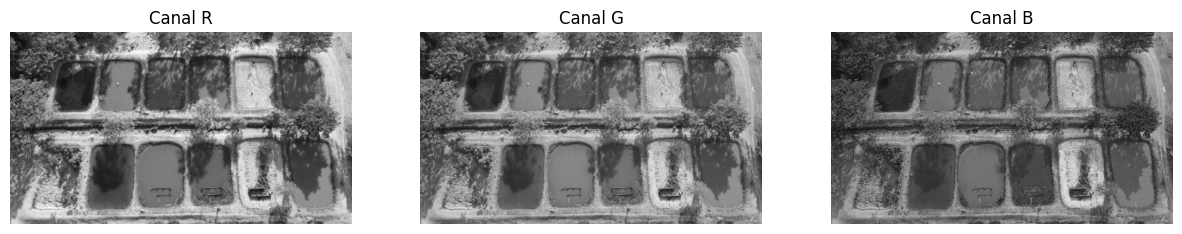

In [57]:
# Separar canales RGB
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# Mostrar dimensiones
print("Dimensión canal R:", R.shape)
print("Dimensión canal G:", G.shape)
print("Dimensión canal B:", B.shape)

# Mostrar canales
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(R, cmap='gray')
plt.title("Canal R")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='gray')
plt.title("Canal G")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("Canal B")
plt.axis("off")

plt.show()

## **🔆Análisis estadístico de los canales RGB**

Aunque los canales RGB pueden verse similares en escala de grises, sus valores numéricos son diferentes. Por esta razón se calculan estadísticas básicas de intensidad para comparar la respuesta de cada canal.

In [58]:
import numpy as np
#numpy es una libreria que maneja matrices y operaciones matematicas
print("Promedio canal R:", np.mean(R))
print("Promedio canal G:", np.mean(G))
print("Promedio canal B:", np.mean(B))

print("Mínimo R:", np.min(R), "Máximo R:", np.max(R))
print("Mínimo G:", np.min(G), "Máximo G:", np.max(G))
print("Mínimo B:", np.min(B), "Máximo B:", np.max(B))

Promedio canal R: 118.86046006944444
Promedio canal G: 116.20692708333333
Promedio canal B: 98.34719075520833
Mínimo R: 0 Máximo R: 255
Mínimo G: 0 Máximo G: 255
Mínimo B: 0 Máximo B: 255


Los valores promedio de intensidad muestran diferencias entre los canales RGB. El canal azul presenta una intensidad promedio menor respecto a los canales rojo y verde, lo cual indica una respuesta distinta de las superficies de agua y vegetación presentes en la escena. Estas diferencias permiten utilizar la información espectral de los canales para tareas de segmentación.

## **Recorte de región de interés**

Para reducir falsas detecciones en árboles y sombras, se seleccionó una región de interés que contiene únicamente el área de las piscinas.

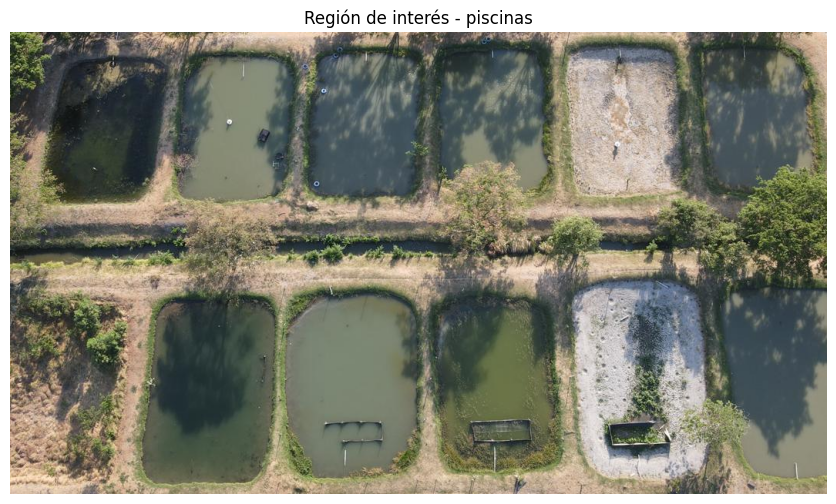

In [59]:
# Recortar región de interés aproximada
# Formato: imagen[y1:y2, x1:x2]
roi = img_rgb[80:680, 120:1180]

plt.figure(figsize=(12,6))
plt.imshow(roi)
plt.title("Región de interés - piscinas")
plt.axis("off")
plt.show()

# **# Conversión de la región de interés a HSV**

La región de interés fue convertida al espacio HSV para resaltar las diferencias entre las piscinas y el entorno cercano.

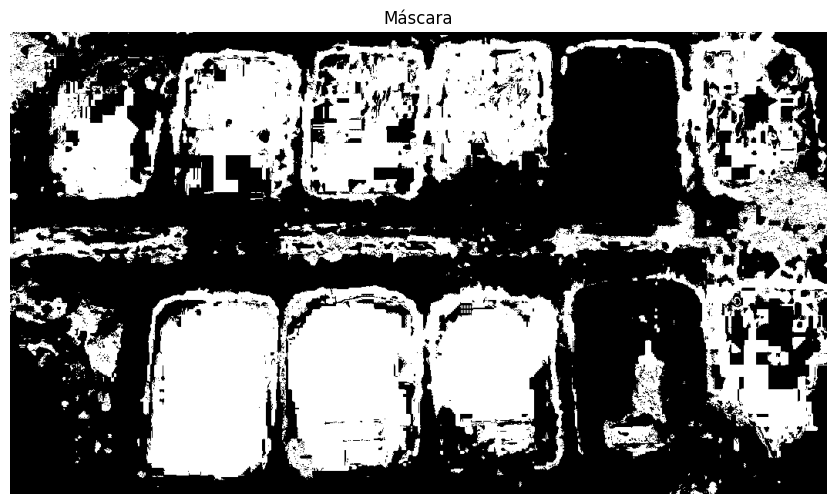

In [60]:
# Convertir ROI a HSV
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

# Nuevos rangos HSV
lower = np.array([35, 20, 20])
upper = np.array([100, 200, 150])

# Crear máscara
mask_roi = cv2.inRange(roi_hsv, lower, upper)

# Mostrar máscara
plt.figure(figsize=(12,6))
plt.imshow(mask_roi, cmap='gray')
plt.title("Máscara")
plt.axis("off")
plt.show()

## **Segmentación inicial mediante umbrales HSV**

Se aplicó una umbralización en el espacio HSV para separar las regiones asociadas al agua de las piscinas. La máscara binaria representa en color blanco las regiones detectadas dentro del rango espectral seleccionado.

# **🔆Separación de regiones mediante Watershed**
Debido a que algunas piscinas aparecían unidas dentro de la máscara binaria, se utilizó el algoritmo Watershed para separar regiones conectadas y mejorar el conteo automático.

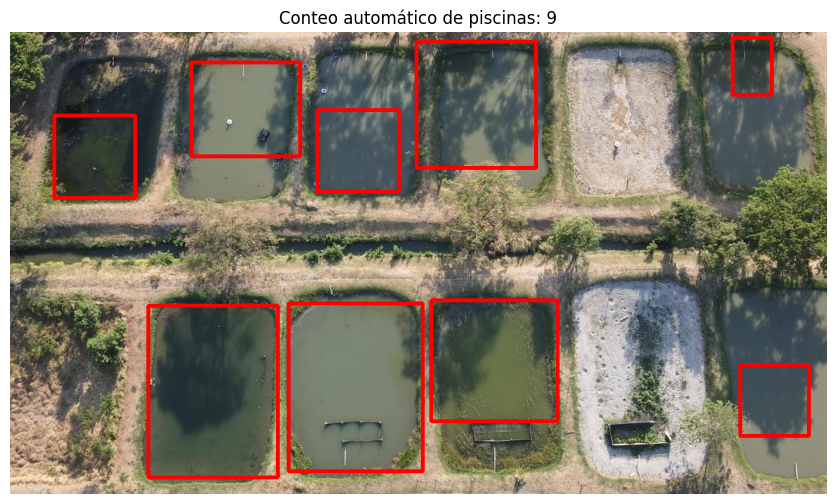

Número de piscinas detectadas automáticamente: 9


In [61]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

resultado = roi.copy()

# Copiamos la máscara
mask = mask_roi.copy()

# ============================================
# 1. LIMPIEZA DE LA MÁSCARA
# ============================================

kernel = np.ones((9, 9), np.uint8)

# Abrir: elimina ruido pequeño y separa zonas pegadas
mask_limpia = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

# OJO: ya no mostramos la máscara blanco y negro

# ============================================
# 2. COMPONENTES CONECTADOS
# ============================================

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_limpia)

boxes = []

for i in range(1, num_labels):  # empieza en 1 porque 0 es fondo
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    if h == 0:
        continue

    ratio = w / h
    relleno = area / (w * h)

    if (
        area > 1800 and
        w > 35 and
        h > 35 and
        0.35 < ratio < 3.2 and
        relleno > 0.25
    ):
        boxes.append((x, y, w, h))

# ============================================
# 3. ELIMINAR CAJAS MUY PARECIDAS
# ============================================

boxes_filtradas = []

for box in boxes:
    x, y, w, h = box
    nueva = True

    for bx, by, bw, bh in boxes_filtradas:

        inter_x1 = max(x, bx)
        inter_y1 = max(y, by)
        inter_x2 = min(x + w, bx + bw)
        inter_y2 = min(y + h, by + bh)

        inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

        area_box = w * h
        area_b = bw * bh

        overlap = inter_area / min(area_box, area_b)

        if overlap > 0.25:
            nueva = False
            break

    if nueva:
        boxes_filtradas.append(box)

# ============================================
# 4. DIBUJAR RESULTADO SOBRE LA IMAGEN ORIGINAL
# ============================================

boxes_filtradas = sorted(boxes_filtradas, key=lambda b: (b[1], b[0]))

for x, y, w, h in boxes_filtradas:
    cv2.rectangle(resultado, (x, y), (x + w, y + h), (255, 0, 0), 3)

contador = len(boxes_filtradas)

plt.figure(figsize=(12,6))
plt.imshow(resultado)
plt.title(f"Conteo automático de piscinas: {contador}")
plt.axis("off")
plt.show()

print("Número de piscinas detectadas automáticamente:", contador)

# **Análisis de sensibilidad de parámetros**

In [62]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import cv2
import numpy as np

def analyze_sensitivity(h_min, s_min, v_min, h_max, s_max, v_max, kernel_size_val, iterations_val, min_area_val):
    # Reconstruct HSV bounds
    lower_bound = np.array([h_min, s_min, v_min])
    upper_bound = np.array([h_max, s_max, v_max])

    # 1. Initial segmentation using HSV thresholds
    mask_roi_current = cv2.inRange(roi_hsv, lower_bound, upper_bound)

    # 2. Mask cleaning (Morphological operations)
    # Ensure kernel_size_val is odd
    kernel_size_val = kernel_size_val if kernel_size_val % 2 != 0 else kernel_size_val + 1
    kernel_current = np.ones((kernel_size_val, kernel_size_val), np.uint8)
    mask_limpia_current = cv2.morphologyEx(mask_roi_current, cv2.MORPH_OPEN, kernel_current, iterations=iterations_val)

    # 3. Connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_limpia_current)

    boxes_current = []
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # Filter based on minimum area. For a more comprehensive analysis, ratio and fill could also be added.
        if area > min_area_val:
            boxes_current.append((x, y, w, h))

    # For simplicity, the filtering of very similar boxes (overlap) is omitted in this sensitivity analysis.
    # The boxes are just sorted for consistent display.
    boxes_filtradas_current = sorted(boxes_current, key=lambda b: (b[1], b[0]))

    # 4. Draw results on the original ROI image
    resultado_current = roi.copy()
    for x, y, w, h in boxes_filtradas_current:
        cv2.rectangle(resultado_current, (x, y), (x + w, y + h), (255, 0, 0), 3)

    contador_current = len(boxes_filtradas_current)

    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(mask_roi_current, cmap='gray')
    axes[0].set_title("Máscara HSV inicial")
    axes[0].axis("off")

    axes[1].imshow(mask_limpia_current, cmap='gray')
    axes[1].set_title("Máscara limpia (morfología)")
    axes[1].axis("off")

    axes[2].imshow(resultado_current)
    axes[2].set_title(f"Conteo automático de piscinas: {contador_current}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Número de piscinas detectadas: {contador_current}")
    print(f"Parámetros usados: H_min={h_min}, S_min={s_min}, V_min={v_min}, H_max={h_max}, S_max={s_max}, V_max={v_max}, Kernel_size={kernel_size_val}, Iterations={iterations_val}, Min_Area={min_area_val}")


# Create widgets for parameters with initial values from the notebook
h_min_slider = widgets.IntSlider(min=0, max=179, step=1, value=35, description='H Min')
s_min_slider = widgets.IntSlider(min=0, max=255, step=1, value=20, description='S Min')
v_min_slider = widgets.IntSlider(min=0, max=255, step=1, value=20, description='V Min')

h_max_slider = widgets.IntSlider(min=0, max=179, step=1, value=100, description='H Max')
s_max_slider = widgets.IntSlider(min=0, max=255, step=1, value=200, description='S Max')
v_max_slider = widgets.IntSlider(min=0, max=255, step=1, value=150, description='V Max')

kernel_size_slider = widgets.IntSlider(min=1, max=21, step=2, value=9, description='Kernel Size') # Kernel size should be odd
iterations_slider = widgets.IntSlider(min=1, max=5, step=1, value=2, description='Iterations')
min_area_slider = widgets.IntSlider(min=100, max=5000, step=50, value=1800, description='Min Area')

# Link widgets to the function
sensitivity_widget = widgets.interactive(
    analyze_sensitivity,
    h_min=h_min_slider, s_min=s_min_slider, v_min=v_min_slider,
    h_max=h_max_slider, s_max=s_max_slider, v_max=v_max_slider,
    kernel_size_val=kernel_size_slider,
    iterations_val=iterations_slider,
    min_area_val=min_area_slider
)

display(sensitivity_widget)

interactive(children=(IntSlider(value=35, description='H Min', max=179), IntSlider(value=20, description='S Mi…

Este código genera una herramienta interactiva para analizar la sensibilidad de los parámetros clave utilizados en la detección de piscinas. Permite ajustar en tiempo real los umbrales HSV para la segmentación inicial, el tamaño del kernel y el número de iteraciones para las operaciones morfológicas de limpieza de la máscara, y el área mínima para considerar un componente conectado como piscina. Al modificar estos parámetros mediante sliders, se visualizan dinámicamente la máscara HSV inicial, la máscara limpia y el resultado final del conteo de piscinas con sus cuadros delimitadores, lo que facilita entender cómo cada ajuste afecta la precisión de la detección.

#**Análisis del resultado**

El algoritmo detectó automáticamente 9 piscinas mediante segmentación HSV, operaciones morfológicas y separación de regiones con Watershed. Algunas piscinas con sombras intensas o baja diferenciación espectral no pudieron segmentarse completamente, lo que afectó el conteo final.

El proceso de segmentación se enfocó en detectar regiones con características espectrales asociadas al agua. Por esta razón, las piscinas vacías o secas no fueron consideradas dentro del conteo automático.

### **Validación cuantitativa**

Se comparó el conteo automático obtenido por el algoritmo con el conteo manual realizado sobre la imagen original.

In [63]:
conteo_real = 10
conteo_automatico = 9

error_absoluto = abs(conteo_real - conteo_automatico)
error_porcentual = (error_absoluto / conteo_real) * 100

print("Conteo manual de referencia:", conteo_real)
print("Conteo automático:", conteo_automatico)
print("Error absoluto:", error_absoluto)
print("Error porcentual:", error_porcentual, "%")

Conteo manual de referencia: 10
Conteo automático: 9
Error absoluto: 1
Error porcentual: 10.0 %
